# Exploratory Data Analysis of the collected data

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# LOAD DATASET

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

save_path = "/content/drive/MyDrive/Capstone-Data Analytics/data/final_dataset_fstoreAPI.csv"
df = pd.read_csv(save_path)

print("Dataset Shape:", df.shape)
df.head()

Mounted at /content/drive
Dataset Shape: (500, 7)


,user_id,review_text,product_id,title,price,category,cleaned_text
0,0,(SOLVED) Python Lexer Reading Numbers Function...,18,MBJ Women's Solid Short Sleeve Boat Neck V,9.85,women's clothing,solved python lexer reading numbers function p...
1,1,Is it possible to &quot;gracefully&quot; stop ...,3,Mens Cotton Jacket,55.99,men's clothing,is it possible to quotgracefullyquot stop a un...
2,2,Are Unicode and ASCII characters the same?,14,Samsung 49-Inch CHG90 144Hz Curved Gaming Moni...,999.99,electronics,are unicode and ascii characters the same
3,3,Why does @XmlJavaTypeAdapter on the root objec...,5,John Hardy Women's Legends Naga Gold & Silver ...,695.00,jewelery,why does xmljavatypeadapter on the root object...
4,4,How to type a decorator as a callable on Python,20,DANVOUY Womens T Shirt Casual Cotton Short,12.99,women's clothing,how to type a decorator as a callable on python


In [3]:
# BASIC INFO OF DATA

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       500 non-null    int64  
 1   review_text   500 non-null    object 
 2   product_id    500 non-null    int64  
 3   title         500 non-null    object 
 4   price         500 non-null    float64
 5   category      500 non-null    object 
 6   cleaned_text  500 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 27.5+ KB


,user_id,product_id,price
count,500.000000,500.000000,500.00000
mean,249.500000,9.632000,175.81432
std,144.481833,5.555024,270.62904
min,0.000000,1.000000,7.95000
25%,124.750000,5.000000,15.99000
50%,249.500000,9.000000,56.99000
75%,374.250000,14.000000,114.00000
max,499.000000,20.000000,999.99000


In [4]:
print("Shape:", df.shape)

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Check missing
print(df.isnull().sum())

Shape: (500, 7)
Duplicates: 0
user_id         0
review_text     0
product_id      0
title           0
price           0
category        0
cleaned_text    0
dtype: int64


In [5]:
# MISSING VALUES
df.isnull().sum()

,0
user_id,0
review_text,0
product_id,0
title,0
price,0
category,0
cleaned_text,0


#### Observations
The dataset shows no critical missing values in key analytical variables such as price and cleaned_text. This ensures reliability in downstream analysis and modeling.

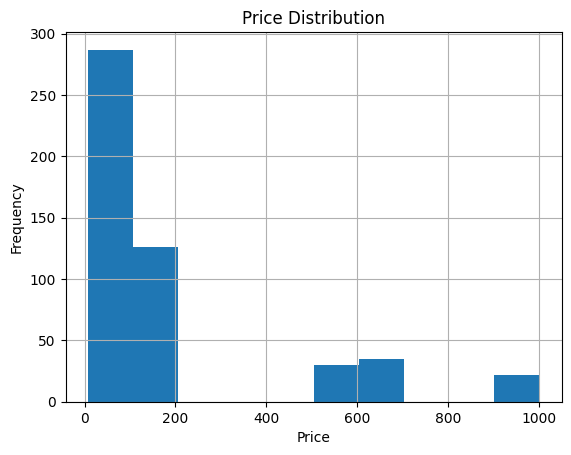

In [6]:
# PRICE DISTRIBUTION

plt.figure()
df['price'].hist()
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [7]:
# PRODUCT FREQUENCY

df['title'].value_counts().head(10)

,count
title,
Mens Casual Premium Slim Fit T-Shirts,40
John Hardy Women's Legends Naga Gold & Silver Dragon Station Chain Bracelet,35
Mens Casual Slim Fit,33
Silicon Power 256GB SSD 3D NAND A55 SLC Cache Performance Boost SATA III 2.5,32
Acer SB220Q bi 21.5 inches Full HD (1920 x 1080) IPS Ultra-Thin,30
Solid Gold Petite Micropave,29
Pierced Owl Rose Gold Plated Stainless Steel Double,28
Mens Cotton Jacket,24
WD 2TB Elements Portable External Hard Drive - USB 3.0,24


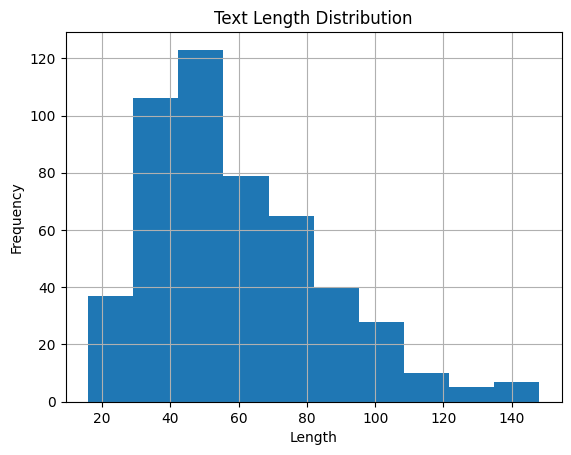

In [8]:
# TEXT LENGTH ANALYSIS

df['text_length'] = df['cleaned_text'].apply(len)

plt.figure()
df['text_length'].hist()
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [9]:
# SENTIMENT ANALYSIS

from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['cleaned_text'].apply(get_sentiment)

In [10]:
# SENTIMENT LABELS

def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

df['sentiment_label'].value_counts()

,count
sentiment_label,
Neutral,382
Positive,65
Negative,53


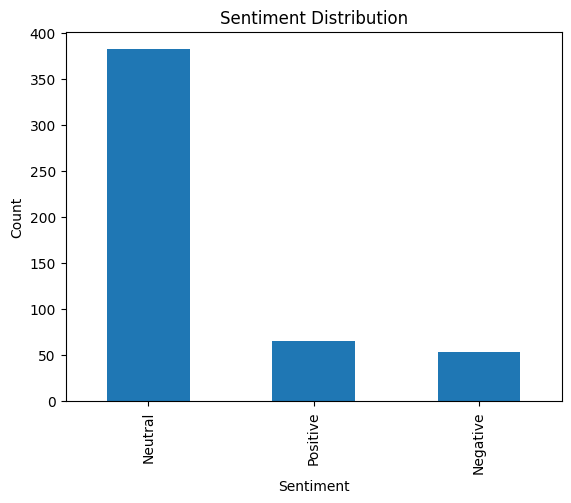

In [11]:
# SENTIMENT DISTRIBUTION

plt.figure()
df['sentiment_label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [12]:
# PRICE VS SENTIMENT

df.groupby('sentiment_label')['price'].mean()

,price
sentiment_label,
Negative,143.920943
Neutral,174.520393
Positive,209.424000


<Figure size 640x480 with 0 Axes>

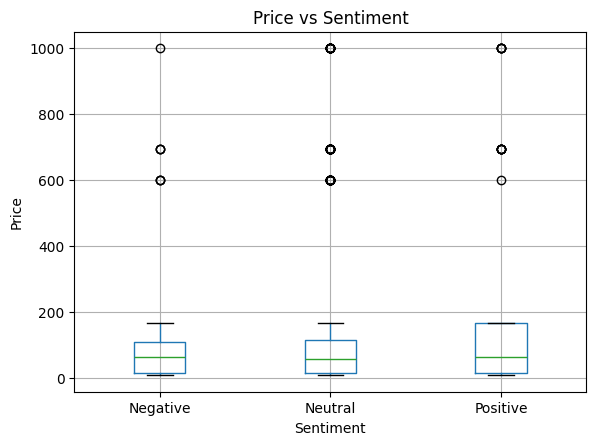

In [13]:
# BOXPLOT ANALYSIS

plt.figure()
df.boxplot(column='price', by='sentiment_label')
plt.title("Price vs Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Price")
plt.show()


## **EDA OBSERVATIONS**


### 1. Dataset Overview

* The final dataset consists of **500 observations and 7 variables**, integrating both structured (price, category) and unstructured (review_text) data.
* The dataset is **fully complete**, with:

  * No missing values
  * No duplicate entries
* This indicates **high data integrity**, making it suitable for downstream statistical and machine learning analysis.

### 2. Product Distribution Insights

* Product representation is **unevenly distributed**, with certain items appearing significantly more frequently than others.
* For example:

  * “Mens Casual Premium Slim Fit T-Shirts” (40 instances)
  * “John Hardy Women's Bracelet” (35 instances)

**Interpretation:**
This suggests a **many-to-one relationship between reviews and products**, where popular products attract more user-generated content.

### 3. Price Distribution Analysis

* The price distribution is **highly right-skewed**, as observed in the histogram:

  * Majority of products fall within the **low to mid-price range (₹10–₹150 approx.)**
  * A small number of products extend into **premium ranges (~₹600–₹1000)**

* Statistical indicators support this:

  * Mean price: **175.81**
  * Median price: **56.99**
  * Maximum: **999.99**

 **Interpretation:**

* The large gap between mean and median confirms **positive skewness**
* Presence of **high-value outliers** may influence model performance and require normalization or transformation

### 4. Text Length Distribution

* Review text length exhibits a **moderately right-skewed distribution**:

  * Most reviews fall within **30–80 words**
  * A smaller number extend beyond **100 words**

**Interpretation:**

* Indicates **variation in user expression depth**
* Supports the need for **text normalization and encoding techniques**
* Longer reviews may carry **richer sentiment signals**, while shorter ones may introduce noise

### 5. Sentiment Distribution

* The dataset is **heavily imbalanced**:

  * Neutral: **382 (~76%)**
  * Positive: **65 (~13%)**
  * Negative: **53 (~11%)**

**Interpretation:**

* Strong dominance of neutral sentiment suggests:

  * Either neutral labeling bias
  * Or inherently informational/technical text (likely from source data)

**Implication for modeling:**

* Classification models may become biased toward the **neutral class**
* Requires techniques such as:

  * Class weighting
  * Resampling

### 6. Relationship Between Price and Sentiment

* Average price by sentiment category:

  * Positive: **209.42**
  * Neutral: **174.52**
  * Negative: **143.92**

**Interpretation:**

* Higher-priced products tend to receive **more positive sentiment**
* Lower-priced products show relatively **higher negative sentiment**

This suggests:

> A potential **positive association between perceived product value and sentiment**


### 7. Category-Level Observations

* Products span multiple categories:

  * Electronics
  * Clothing (men’s and women’s)
  * Jewelry

**Interpretation:**

* The dataset captures **cross-category variation**, enhancing generalizability
* However, category-specific biases may exist and should be tested during modeling


### 8. Data Quality Validation

* No missing values across all variables
* No duplicate records after cleaning
* Text preprocessing successfully standardized inputs

 **Conclusion:**
The dataset is **analysis-ready**, with minimal preprocessing required for modeling.

#### INSIGHT

“The exploratory analysis reveals a structurally sound dataset with meaningful variability in both numerical and textual features. Key patterns, including price skewness and sentiment imbalance, highlight important considerations for model development and interpretation.”